# Part B: Data Understanding And Preparation

In [7]:
import pandas as pd

# Load the dataset
df = pd.read_csv("RealEstate_HousePrice_Dataset_4200 .csv")

df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [9]:
print(df.columns)

Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage',
       'has_pool', 'renovation_years_ago', 'house_price_inr'],
      dtype='object')


In [12]:
# Identify Independent and Dependent Variables
# Independent variables
X = df.drop(['house_id', 'house_price_inr'], axis=1)

print(X.columns)


Index(['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years',
       'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool',
       'renovation_years_ago'],
      dtype='object')


In [13]:

# Dependent variable
y = df['house_price_inr']

print(y.head())

0    40275084
1    26812029
2    29315677
3    47712959
4    17724566
Name: house_price_inr, dtype: int64


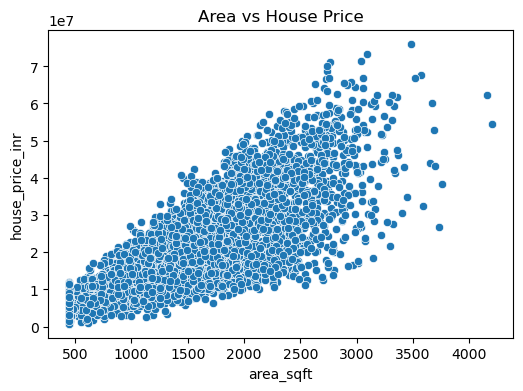

In [15]:
#Visualize Relationships Between Features and Target Variable

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.scatterplot(
    x='area_sqft',
    y='house_price_inr',
    data=df
)

plt.title("Area vs House Price")

plt.show()

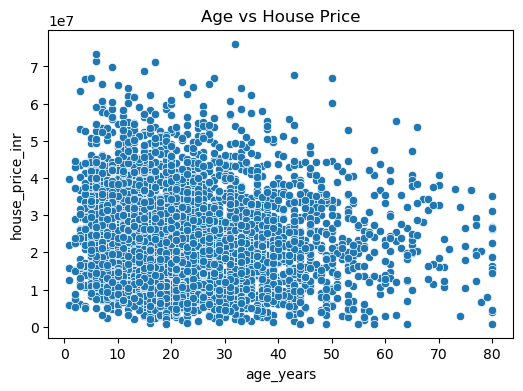

In [16]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='age_years',
    y='house_price_inr',
    data=df
)

plt.title("Age vs House Price")

plt.show()

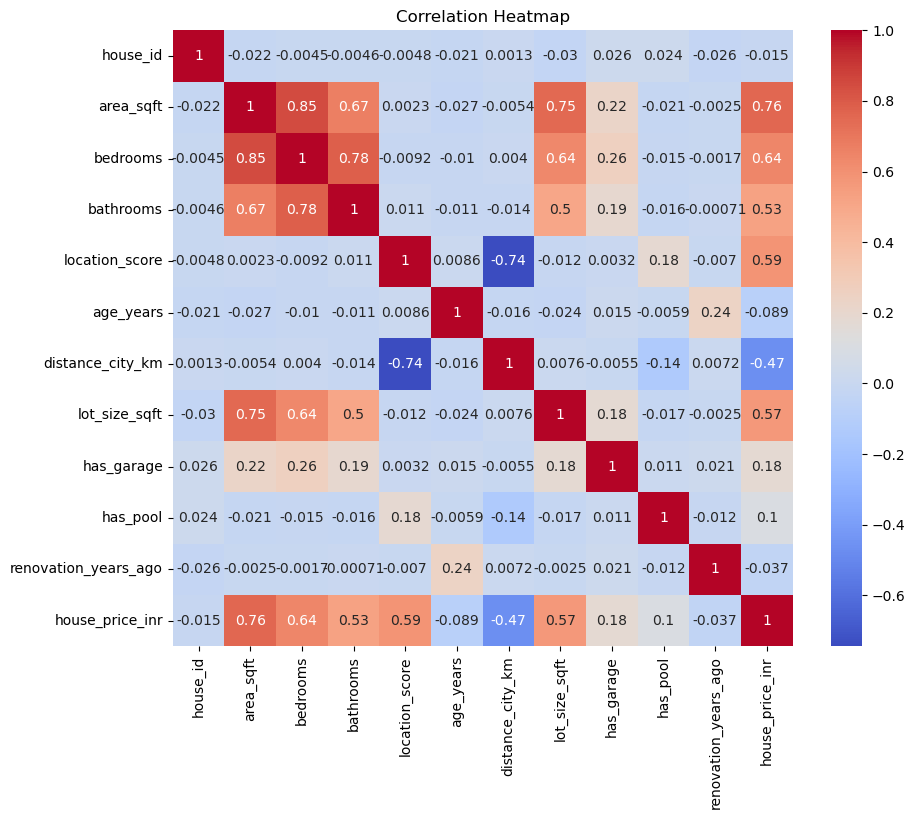

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
# Split the Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)

print("X_test:", X_test.shape)

print("y_train:", y_train.shape)

print("y_test:", y_test.shape)

X_train: (3360, 10)
X_test: (840, 10)
y_train: (3360,)
y_test: (840,)


# Part C: Simple Linear Regression

In [22]:
# Implement Simple Linear Regression

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
# Select one feature
X = df[['area_sqft']]

# Target variable
y = df['house_price_inr']

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
# Predict values
y_pred = model.predict(X_test)

print(y_pred[:5])

[39041695.88003895 31356206.88019853 16525771.65900365 31626148.07085446
 21121327.90647442]


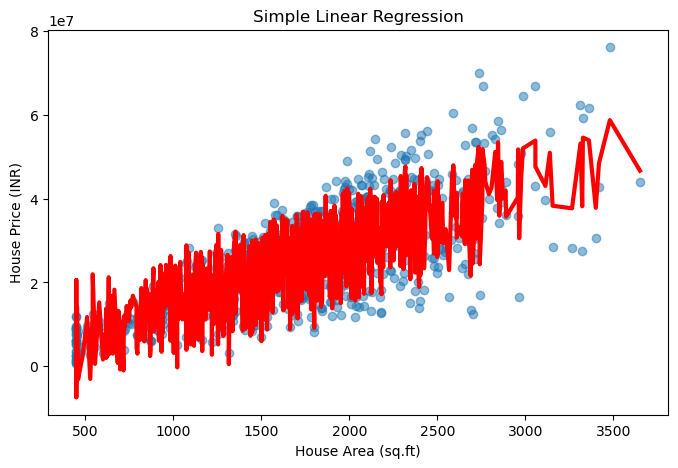

In [34]:
# Plot the regression line and interpret slope and intercept
# Create a temporary dataframe
plot_data = pd.DataFrame({
    'area_sqft': X_test['area_sqft'],
    'actual_price': y_test,
    'predicted_price': y_pred
})

# Sort by house area
plot_data = plot_data.sort_values('area_sqft')

# Plot graph
plt.figure(figsize=(8,5))

# Actual data points
plt.scatter(
    plot_data['area_sqft'],
    plot_data['actual_price'],
    alpha=0.5
)

# Best fit regression line
plt.plot(
    plot_data['area_sqft'],
    plot_data['predicted_price'],
    color='red',
    linewidth=3
)

plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price (INR)")
plt.title("Simple Linear Regression")

plt.show()

In [28]:
print("Slope:", model.coef_[0])

print("Intercept:", model.intercept_)

Slope: 13795.943618350566
Intercept: -14766762.745674554


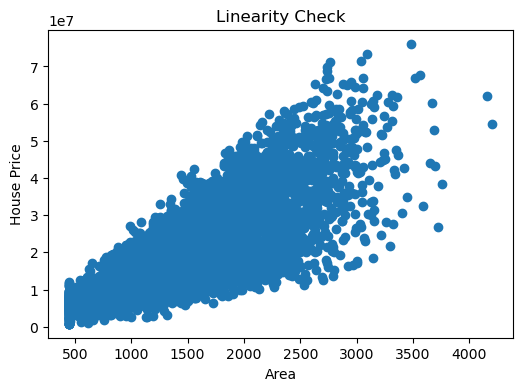

In [30]:
# Validate linear regression assumptions using plots and observations

plt.figure(figsize=(6,4))

plt.scatter(
    df['area_sqft'],
    df['house_price_inr']
)

plt.xlabel("Area")

plt.ylabel("House Price")

plt.title("Linearity Check")

plt.show()

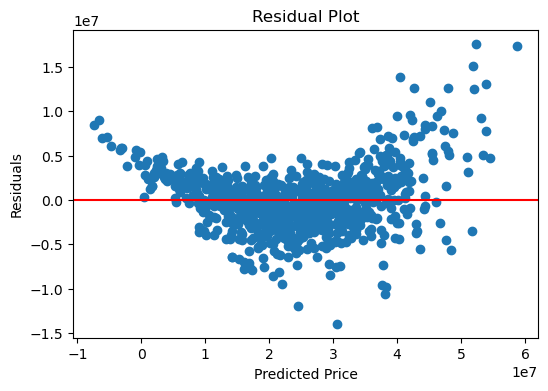

In [35]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Price")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

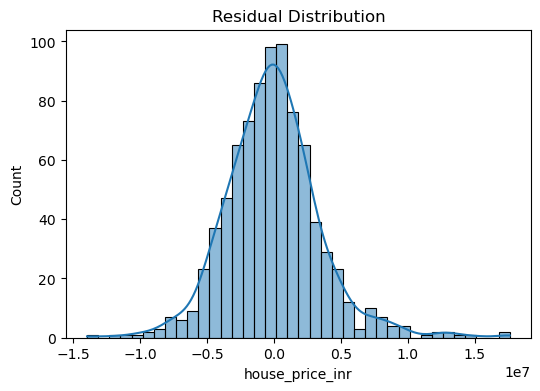

In [36]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

# Part D: Model Evaluation Metrics

In [37]:
#Calculate Metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

n = len(y_test)

p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("MSE:", mse)

print("MAE:", mae)

print("RMSE:", rmse)

print("R² Score:", r2)

print("Adjusted R²:", adjusted_r2)

MSE: 12592918884127.656
MAE: 2604991.4061556915
RMSE: 3548650.290480545
R² Score: 0.9177606877509895
Adjusted R²: 0.9167686574464176


## Interpretation of Evaluation Metrics

### Mean Squared Error (MSE)
MSE measures the average squared difference between actual and predicted values. A lower value indicates better model performance.

### Mean Absolute Error (MAE)
MAE measures the average absolute difference between actual and predicted values. A lower value means the predictions are more accurate.

### Root Mean Squared Error (RMSE)
RMSE measures the prediction error in the original unit (INR). A lower value indicates better performance.

### R² Score
R² Score shows how well the model explains the variation in house prices. Values closer to 1 indicate a better model.

### Adjusted R² Score
Adjusted R² is similar to R² but also considers the number of features used in the model. It provides a more reliable evaluation.

# Part E: Multiple Linear Regression

In [38]:
#Implement Multiple Linear Regression using all relevant features

# Independent variables
X = df.drop(['house_id', 'house_price_inr'], axis=1)

# Dependent variable
y = df['house_price_inr']



In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
from sklearn.linear_model import LinearRegression

mlr_model = LinearRegression()

mlr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
y_pred_mlr = mlr_model.predict(X_test)

print(y_pred_mlr[:5])

[39041695.88003895 31356206.88019853 16525771.65900365 31626148.07085446
 21121327.90647442]


In [42]:
#Compare its performance with Simple Linear Regression

from sklearn.metrics import r2_score

r2_mlr = r2_score(y_test, y_pred_mlr)

print("Multiple Linear Regression R² Score:", r2_mlr)


Multiple Linear Regression R² Score: 0.9177606877509895


## Comparison

Simple Linear Regression uses only one feature (House Area).

Multiple Linear Regression uses all relevant features.

Multiple Linear Regression generally gives better performance because it uses more information.

## Explanation

Performance improves because Multiple Linear Regression uses multiple features such as bedrooms, bathrooms, location score and property age.

More useful information helps the model make better predictions.

Performance may degrade if irrelevant or highly correlated features are included.

# Part F: Polynomial Regression

In [43]:
# Implement Polynomial Regression (Degree = 2)

from sklearn.preprocessing import PolynomialFeatures

X = df[['area_sqft']]

y = df['house_price_inr']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)

X_test_poly = poly.transform(X_test)

In [49]:
slr_model = LinearRegression()

slr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
y_pred = slr_model.predict(X_test)

In [47]:
print(y_pred_poly[:5])

[34385892.28574474 27442582.20006674 26884746.34934368 21914765.18169476
 31105566.22813054]


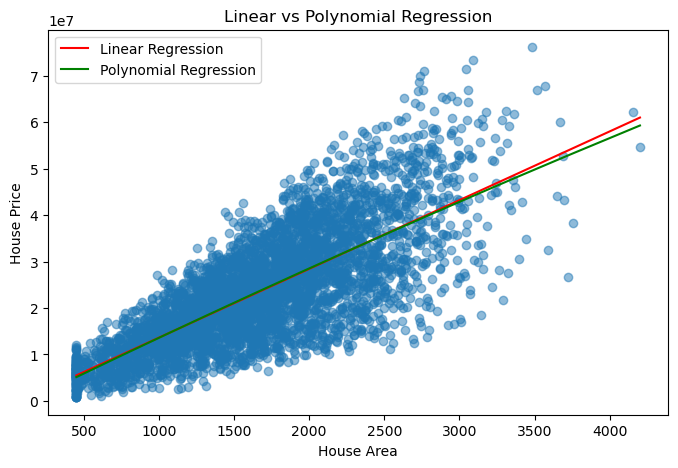

In [51]:
#Compare Linear vs Polynomial Regression visually and numerically

# Sort values

sorted_df = df.sort_values('area_sqft')

X_sorted = sorted_df[['area_sqft']]

plt.figure(figsize=(8,5))

plt.scatter(
    df['area_sqft'],
    df['house_price_inr'],
    alpha=0.5
)

plt.plot(
    X_sorted,
    slr_model.predict(X_sorted),
    color='red',
    label='Linear Regression'
)

plt.plot(
    X_sorted,
    poly_model.predict(poly.transform(X_sorted)),
    color='green',
    label='Polynomial Regression'
)

plt.legend()

plt.xlabel("House Area")

plt.ylabel("House Price")

plt.title("Linear vs Polynomial Regression")

plt.show()

## Overfitting and Underfitting

Underfitting:
- The model is too simple.
- It performs poorly on both training and testing data.

Overfitting:
- The model is too complex.
- It performs very well on training data but poorly on testing data.

If Polynomial Regression gives extremely high training performance but lower testing performance, it may indicate overfitting.

## Overfitting and Underfitting

Underfitting:
- The model is too simple.
- It performs poorly on both training and testing data.

Overfitting:
- The model is too complex.
- It performs very well on training data but poorly on testing data.

If Polynomial Regression gives extremely high training performance but lower testing performance, it may indicate overfitting.

# Part G: Gradient Descent Optimization

## Gradient Descent

Gradient Descent is an optimization algorithm used to minimize errors by finding the best values of model parameters.

It repeatedly adjusts the parameters in the direction that reduces the error until the model reaches the minimum error.

In [52]:
#Implement Batch Gradient Descent

import numpy as np

X = np.array(df['area_sqft'])

y = np.array(df['house_price_inr'])

m = 0
b = 0

learning_rate = 0.0000001

epochs = 100

n = len(X)

for i in range(epochs):

    y_pred = m * X + b

    dm = (-2/n) * np.sum(X * (y - y_pred))

    db = (-2/n) * np.sum(y - y_pred)

    m = m - learning_rate * dm

    b = b - learning_rate * db

print("Slope:", m)

print("Intercept:", b)

Slope: 14263.395276489371
Intercept: 4.679087473250235


In [53]:
#Implement Stochastic Gradient Descent (SGD)

m = 0

b = 0

learning_rate = 0.0000001

epochs = 10

for epoch in range(epochs):

    for i in range(len(X)):

        x = X[i]

        y_actual = y[i]

        y_pred = m*x + b

        dm = -2*x*(y_actual-y_pred)

        db = -2*(y_actual-y_pred)

        m = m - learning_rate*dm

        b = b - learning_rate*db

print("Slope:", m)

print("Intercept:", b)

Slope: 16808.580935183323
Intercept: -1357.1032766221035


In [54]:
#Implement Mini-Batch Gradient Descent

m = 0

b = 0

learning_rate = 0.0000001

batch_size = 32

epochs = 10

for epoch in range(epochs):

    for i in range(0, len(X), batch_size):

        X_batch = X[i:i+batch_size]

        y_batch = y[i:i+batch_size]

        n = len(X_batch)

        y_pred = m*X_batch + b

        dm = (-2/n)*np.sum(X_batch*(y_batch-y_pred))

        db = (-2/n)*np.sum(y_batch-y_pred)

        m = m - learning_rate*dm

        b = b - learning_rate*db

print("Slope:", m)

print("Intercept:", b)

Slope: 16702.071161405587
Intercept: -26.714856971433377


## Compare convergence behavior and training time


Batch Gradient Descent:
- Uses the entire dataset.
- Slower but more stable.

Stochastic Gradient Descent (SGD):
- Uses one data point at a time.
- Faster but less stable.

Mini-Batch Gradient Descent:
- Uses small batches of data.
- Provides a balance between speed and stability.

# Part H: Bias-Variance & Model Diagnostics

##  Bias and Variance Analysis

Simple Linear Regression:
- High Bias
- Low Variance

Multiple Linear Regression:
- Balanced Bias and Variance

Polynomial Regression:
- Low Bias
- High Variance

## Model Complexity

Simple models may underfit and produce high bias.

Complex models may overfit and produce high variance.

A balanced model gives better predictions.

## Best Model

Multiple Linear Regression provides the best balance between bias and variance.

It uses multiple features while avoiding excessive complexity.

# Part I: Final Analysis and Reporting

## Final Analysis Report

## Best Performing Model

Multiple Linear Regression performed the best because it used all relevant features such as house area, bedrooms, bathrooms, location score, and property age.

## Impact of Gradient Descent Optimization

Gradient Descent helped optimize model parameters by reducing prediction errors. Mini-Batch Gradient Descent provided a good balance between speed and stability.

## Evidence of Overfitting and Underfitting

Simple Linear Regression showed signs of underfitting because it used only one feature.

Polynomial Regression may lead to overfitting if the degree is too high.

Multiple Linear Regression provided a balanced performance.

## Practical Business Interpretation

The model can help real estate companies estimate house prices more accurately.

Factors such as area, location, number of bedrooms, and property age have a significant impact on house prices.

## Final Conclusion

In this project, different supervised learning models were implemented and evaluated for house price prediction.

Simple Linear Regression, Multiple Linear Regression, and Polynomial Regression were compared.

Multiple Linear Regression produced the best overall performance because it used multiple relevant features.

The project also demonstrated Gradient Descent optimization, model evaluation metrics, and the concepts of bias, variance, overfitting, and underfitting.

Overall, the project successfully predicted house prices and provided useful insights for real-world business applications.